Data Loaded Successfully
   diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0          1        17.99         10.38          122.80     1001.0   
1          1        20.57         17.77          132.90     1326.0   
2          1        19.69         21.25          130.00     1203.0   
3          1        11.42         20.38           77.58      386.1   
4          1        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   symmetry_mean  ...  radius_worst  texture_worst  perimeter_worst  \
0         0.2419  ..

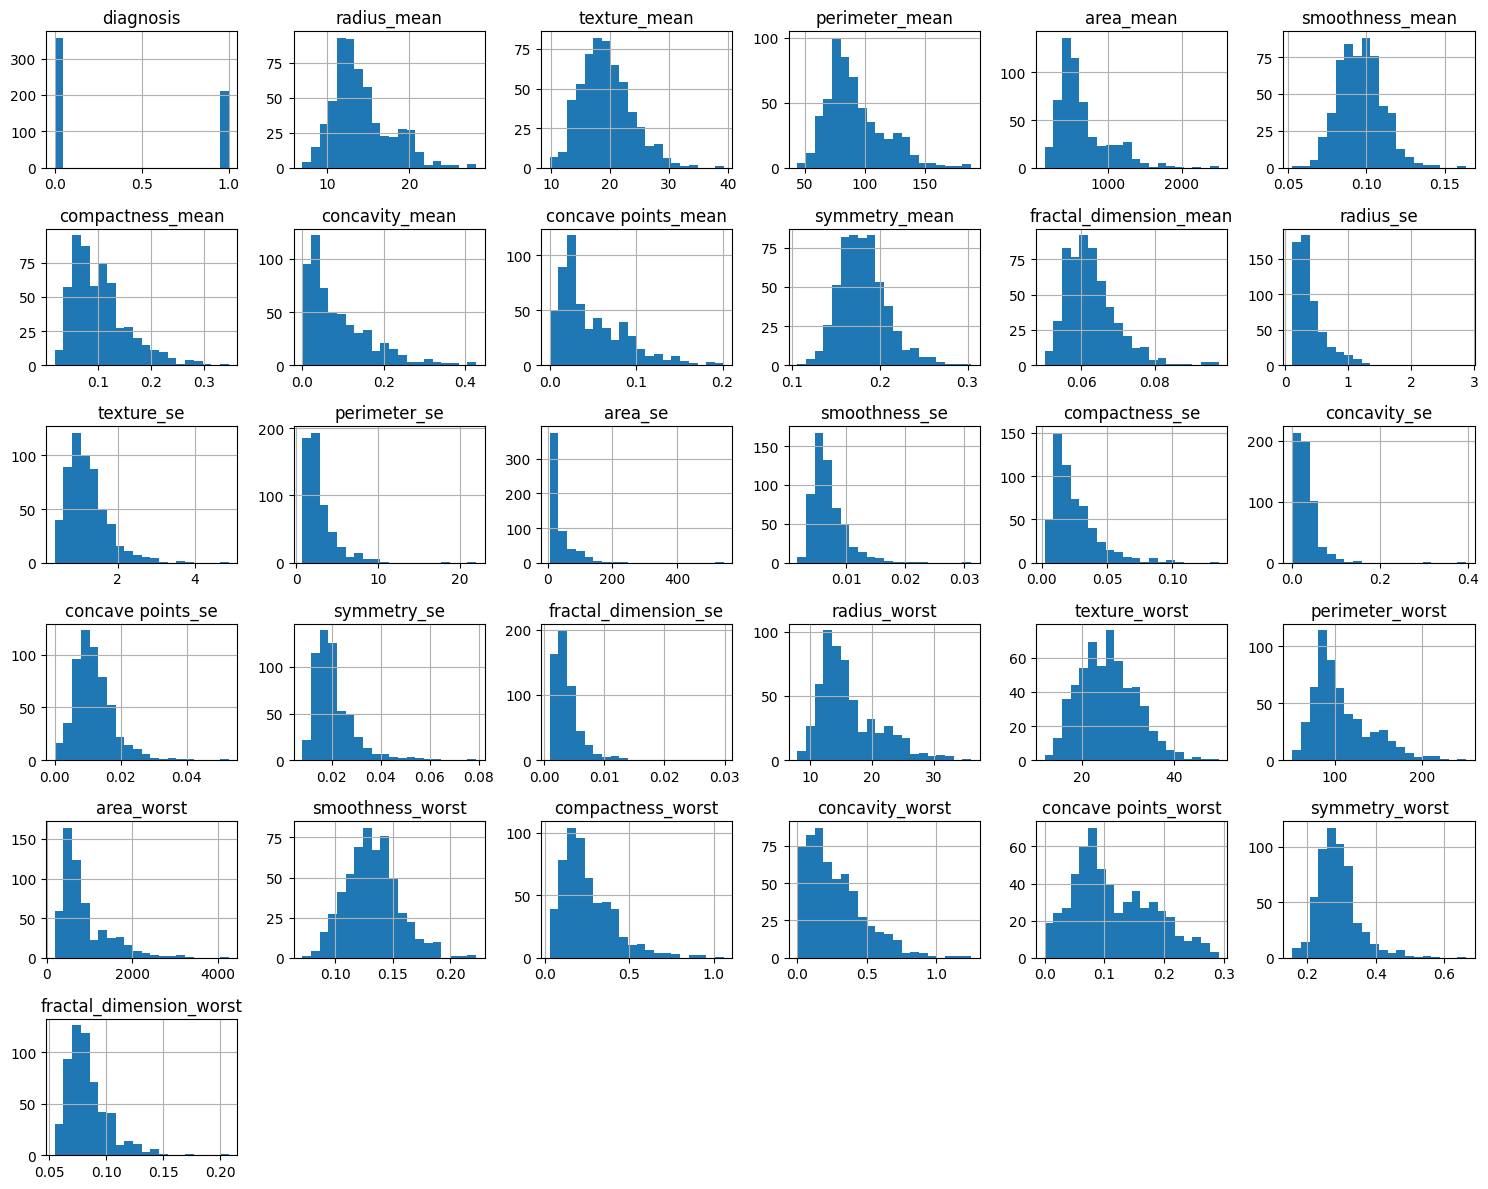

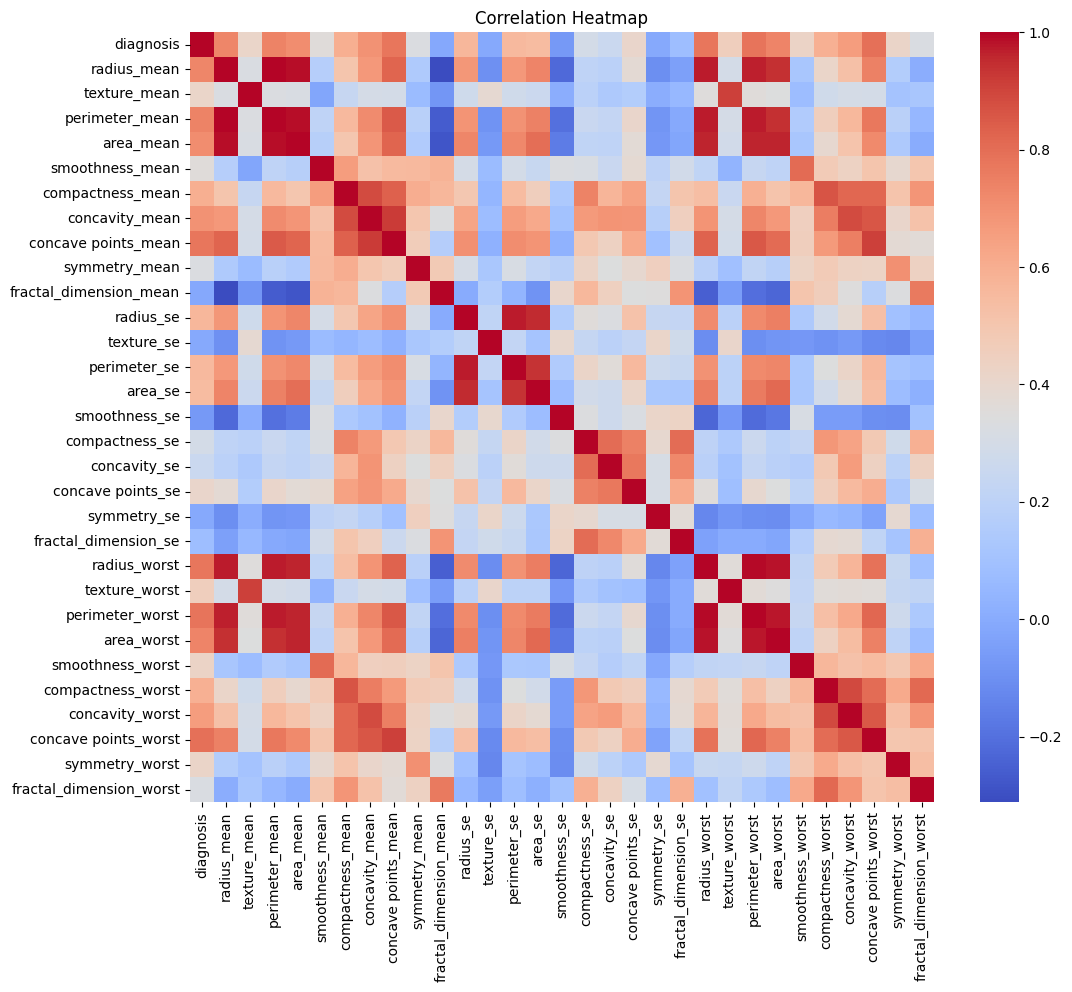


Data Split Completed
X_train: (455, 30)
X_test : (114, 30)

Scaling Done
X_train_scaled: (455, 30)
X_test_scaled : (114, 30)

KNN Model Trained
K = 5

Model Evaluation
----------------
Accuracy: 0.9474

Classification Report:
               precision    recall  f1-score   support

   Benign (0)       0.96      0.96      0.96        71
Malignant (1)       0.93      0.93      0.93        43

     accuracy                           0.95       114
    macro avg       0.94      0.94      0.94       114
 weighted avg       0.95      0.95      0.95       114



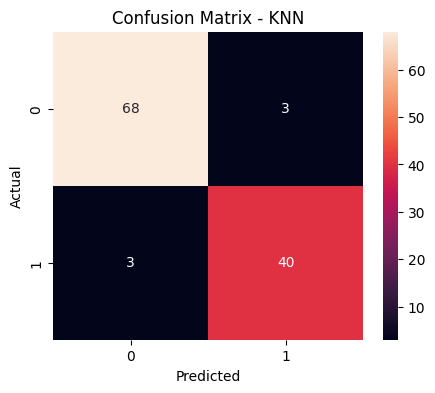

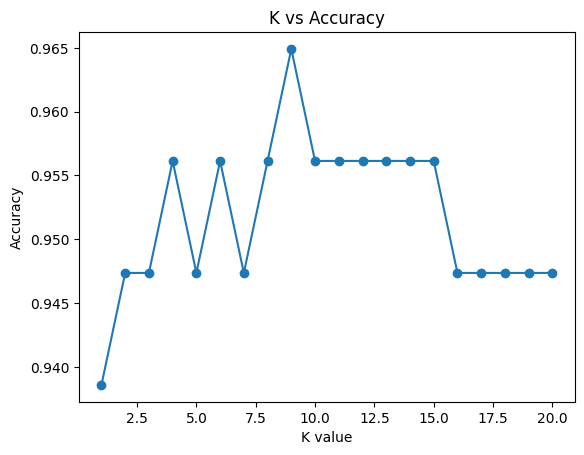

Saved in: c:\Users\Hp\.antigravity


In [1]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# ==============================
# 2. LOAD & CLEAN DATA
# ==============================
df = pd.read_csv("Cancer.csv")

# Drop unnecessary columns
df = df.drop(columns=["id", "Unnamed: 32"])

# Convert diagnosis to numeric
df['diagnosis'] = df['diagnosis'].map({'M':1, 'B':0})

print("Data Loaded Successfully")
print(df.head())


# ==============================
# 3. BASIC EDA
# ==============================
print("\nDataset Info:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())


# ==============================
# 4. DISTRIBUTION PLOTS
# ==============================
df.hist(bins=20, figsize=(15,12))
plt.tight_layout()
plt.show()


# ==============================
# 5. CORRELATION HEATMAP
# ==============================
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


# ==============================
# 6. TRAIN-TEST SPLIT
# ==============================
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nData Split Completed")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)


# ==============================
# 7. FEATURE SCALING
# ==============================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nScaling Done")
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)


# ==============================
# 8. KNN MODEL
# ==============================
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

print("\nKNN Model Trained")
print("K = 5")


# ==============================
# 9. PREDICTIONS
# ==============================
y_pred_knn = knn.predict(X_test_scaled)


# ==============================
# 10. EVALUATION
# ==============================
accuracy = accuracy_score(y_test, y_pred_knn)

print("\nModel Evaluation")
print("----------------")
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn, 
      target_names=["Benign (0)", "Malignant (1)"]))


# ==============================
# 11. CONFUSION MATRIX
# ==============================
cm = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - KNN")
plt.show()


# ==============================
# 12. K VALUE TUNING (OPTIONAL)
# ==============================
accuracies = []

for k in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, pred))

plt.plot(range(1,21), accuracies, marker='o')
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy")
plt.show()
import pickle

with open("knn_model.pkl", "wb") as f:
    pickle.dump(knn, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
    import os
print("Saved in:", os.getcwd())





In [1]:
import numpy as np
import pandas as pd
import pickle

# =========================
# LOAD MODEL + SCALER
# =========================
with open("knn_model.pkl", "rb") as f:
    model = pickle.load(f)

with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

# =========================
# LOAD DATA (FOR FEATURE NAMES)
# =========================
df = pd.read_csv("Cancer.csv")
df = df.drop(columns=["id", "Unnamed: 32"])
df['diagnosis'] = df['diagnosis'].map({'M':1, 'B':0})

X = df.drop(columns=['diagnosis'])

# =========================
# TAKE USER INPUT
# =========================
print("\nEnter values for all features:\n")

inputs = []
for feature in X.columns:
    val = float(input(f"{feature}: "))
    inputs.append(val)

# =========================
# CONVERT TO DATAFRAME
# =========================
data = pd.DataFrame([inputs], columns=X.columns)

# Scale
data_scaled = scaler.transform(data)

# =========================
# PREDICT
# =========================
prediction = model.predict(data_scaled)
proba = model.predict_proba(data_scaled)

# =========================
# OUTPUT
# =========================
print("\nPrediction Result:")

if prediction[0] == 1:
    print("⚠️ Malignant (Cancer Detected)")
    print(f"Confidence: {proba[0][1]*100:.2f}%")
else:
    print("✅ Benign (No Cancer Detected)")
    print(f"Confidence: {proba[0][0]*100:.2f}%")


Enter values for all features:


Prediction Result:
✅ Benign (No Cancer Detected)
Confidence: 80.00%
